# YOLO11n Dataset 준비
- dataset 다운로드

### 1. COCO 2017 Dataset

In [ ]:
from ultralytics.utils.downloads import download
from pathlib import Path

# 1. COCO 2017 공식 다운로드 주소 지정
coco_urls = [
    "http://images.cocodataset.org/zips/train2017.zip",        # Train 이미지 (약 18GB)
    "http://images.cocodataset.org/zips/val2017.zip",          # Val 이미지 (약 1GB)
    "http://images.cocodataset.org/zips/test2017.zip",         # Test 이미지 (약 6GB)
    "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"  # 라벨 정보 (약 240MB)
]

# 2. 저장 경로 지정 (프로젝트 폴더 내 datasets/coco)
save_dir = Path("./datasets/coco-dataset").resolve()

print("=== COCO 데이터셋 다운로드 및 자동 압축 해제 시작 ===")

# 3. 다운로드 및 자동 압축 해제 실행
# unzip=True: 다운로드 완료 후 자동 압축 해제 수행
# delete=True: 압축 해제가 완료된 원본 .zip 파일 자동 삭제 처리
download(urls=coco_urls, dir=save_dir, unzip=True, delete=True)

print("=== COCO 데이터셋 빌드 완료 ===")


### 2. 킥보드1 Computer Vision Dataset

In [2]:
from roboflow import Roboflow

rf = Roboflow(api_key="4ldbiJwQ0uNDJ8oNJhEs")
project = rf.workspace("test-w9qag").project("-1-pshya-r07yo")
version = project.version(1)
dataset = version.download("yolov11", location="datasets/kickboard-dataset")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to datasets/kickboard-dataset in yolov11:: 100%|██████████| 5019/5019 [00:01<00:00, 3298.45it/s]


### 3. bollard Computer Vision Dataset

In [3]:
from roboflow import Roboflow
rf = Roboflow(api_key="4ldbiJwQ0uNDJ8oNJhEs")
project = rf.workspace("test-w9qag").project("bollard-v2gn5-t7lrj-ycf6t")
version = project.version(1)
dataset = version.download("yolov11", location="datasets/bollard-dataset")              

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to datasets/bollard-dataset in yolov11:: 100%|██████████| 3389/3389 [00:00<00:00, 3703.32it/s]


# 라벨링 수정
- 라벨링 데이터를 12개 라벨링 데이터로 변경
- seg 형식 데이터를 bbox 형식으로 전처리

| 클래스 ID | 클래스명 (영문) | 설명 | 출처 및 병합 정책 |
| :---: | :--- | :--- | :--- |
| **0** | `person` | 보행자 | COCO 원본 필터링 (단독 보행자 이미지는 정제 삭제) |
| **1** | `bicycle` | 자전거 | COCO 원본 필터링 |
| **2** | `car` | 승용차 | COCO 원본 필터링 |
| **3** | `motorcycle` | 오토바이 | COCO 원본 필터링 |
| **4** | `bus` | 버스 | COCO 원본 필터링 |
| **5** | `truck` | 트럭 | COCO 원본 필터링 |
| **6** | `traffic light` | 신호등 | COCO 원본 필터링 |
| **7** | `stop sign` | 정지 표지판 | COCO 원본 필터링 |
| **8** | `bench` | 벤치 | COCO 원본 필터링 |
| **9** | `dog` | 반려견 | COCO 원본 필터링 |
| **10** | `bollard` | 볼라드 | Roboflow 병합 (원본 0번 → 10번으로 이식) |
| **11** | `kickboard` | 전동 킥보드 | 통합 데이터셋 추가 클래스 (원본 0번 → 11번으로 이식) |

### COCO dataset에서 필요한 라벨만 남기고 나머지 삭제 및 라벨링 번호 수정

In [4]:
import os
import shutil
from pathlib import Path

# ==============================================================================
# 경로 및 데이터 정제 정책
# ==============================================================================
# 정제할 대상 COCO 데이터셋 루트 경로
COCO_ROOT = Path("./datasets/coco-dataset").resolve()

# 이미지 파일 매칭을 위한 확장자 목록
IMG_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

# 데이터 정제 정책 옵션 (True: 활성화, False: 비활성화)
REMOVE_EMPTY_IMAGES = True        # 필터링 후 감지 대상이 하나도 없는 빈 이미지를 완전히 삭제할지 여부
REMOVE_PERSON_ONLY_IMAGES = True  # 데이터 개수 편향 예방을 위해 보행자(Class 0)만 단독으로 남은 이미지 삭제 여부

# ------------------------------------------------------------------------------
# 클래스 매핑 정의 (COCO 원본 ID -> 새로운 통합 ID)
# ------------------------------------------------------------------------------
CLASS_MAP = {
    0: 0,   # person (원본 0 -> 새 0)
    1: 1,   # bicycle (원본 1 -> 새 1)
    2: 2,   # car (원본 2 -> 새 2)
    3: 3,   # motorcycle (원본 3 -> 새 3)
    5: 4,   # bus (원본 5 -> 새 4)
    7: 5,   # truck (원본 7 -> 새 5)
    9: 6,   # traffic light (원본 9 -> 새 6)
    11: 7,  # stop sign (원본 11 -> 새 7)
    13: 8,  # bench (원본 13 -> 새 8)
    16: 9   # dog (원본 16 -> 새 9)
}

# ==============================================================================
# 라벨 정제 프로세스 실행 함수
# ==============================================================================
def clean_and_remap_coco():
    # 처리 대상 스플릿 폴더들
    splits = ["train2017", "val2017", "test2017"]
    
    labels_dir_root = COCO_ROOT / "labels"
    images_dir_root = COCO_ROOT / "images"
    
    print("=== COCO 데이터셋 필터링 및 인덱스 리매핑 시작 ===")
    
    for split in splits:
        split_lbl_dir = labels_dir_root / split
        split_img_dir = images_dir_root / split
            
        print(f"\n[{split} 분할 처리 중...]")
        
        modified_files = 0
        deleted_empty = 0
        deleted_person_only = 0
        
        # 해당 스플릿의 모든 txt 라벨 파일 스캔
        for txt_path in split_lbl_dir.glob("*.txt"):
            stem = txt_path.stem
            
            # 대응되는 이미지 파일 찾기
            img_path = None
            if split_img_dir.exists():
                for ext in IMG_EXTS:
                    temp_img_path = split_img_dir / f"{stem}{ext}"
                    if temp_img_path.exists():
                        img_path = temp_img_path
                        break
            
            # 라벨 파일 읽어서 매핑 대상만 추출
            new_lines = []
            classes_in_file = set()
            
            with open(txt_path, "r", encoding="utf-8") as f:
                for line in f:
                    parts = line.strip().split()
                    if not parts:
                        continue
                    
                    try:
                        old_cls = int(float(parts[0]))
                    except ValueError:
                        continue
                    
                    # 클래스 ID 교체 후 저장
                    if old_cls in CLASS_MAP:
                        new_cls = CLASS_MAP[old_cls]
                        parts[0] = str(new_cls)
                        new_lines.append(" ".join(parts))
                        classes_in_file.add(new_cls)
            
            # --- 데이터 정제 정책 적용 ---
            
            # 정책: 필터링 후 검출 대상이 아예 없는 경우
            if not new_lines:
                if REMOVE_EMPTY_IMAGES:
                    # 라벨 파일 삭제
                    if txt_path.exists():
                        txt_path.unlink()
                    # 대응되는 이미지 파일도 함께 세트로 제거
                    if img_path and img_path.exists():
                        img_path.unlink()
                    deleted_empty += 1
                else:
                    # 삭제 옵션이 꺼져 있으면 빈 텍스트 파일로 저장
                    with open(txt_path, "w", encoding="utf-8") as f:
                        f.write("")
                    modified_files += 1
                continue
                
            # 정책: 보행자(Class 0)만 단독으로 존재하는 이미지 필터링
            if classes_in_file == {0}:
                if REMOVE_PERSON_ONLY_IMAGES:
                    if txt_path.exists():
                        txt_path.unlink()
                    if img_path and img_path.exists():
                        img_path.unlink()
                    deleted_person_only += 1
                else:
                    # 삭제 옵션이 꺼져 있으면 필터링된 라벨 정상 덮어쓰기
                    with open(txt_path, "w", encoding="utf-8") as f:
                        f.write("\n".join(new_lines) + "\n")
                    modified_files += 1
                continue
            
            # 일반적인 정제 완료 라벨 저장
            with open(txt_path, "w", encoding="utf-8") as f:
                f.write("\n".join(new_lines) + "\n")
            modified_files += 1
            
        print(f"  -> {split} 완료: 정제/리매핑 완료={modified_files:,}장")
        if REMOVE_EMPTY_IMAGES:
            print(f"  -> 빈 라벨 삭제 완료={deleted_empty:,}장")
        if REMOVE_PERSON_ONLY_IMAGES:
            print(f"  -> Person 단독 파일 삭제 완료={deleted_person_only:,}장")

    print("\n🎉 모든 COCO 데이터셋 라벨 필터링 및 리매핑이 정상 종료되었습니다!")

if __name__ == "__main__":
    clean_and_remap_coco()


=== COCO 데이터셋 필터링 및 인덱스 리매핑 시작 ===

[train2017 분할 처리 중...]
  -> train2017 완료: 정제/리매핑 완료=29,419장
  -> 빈 라벨 삭제 완료=42,493장
  -> Person 단독 파일 삭제 완료=45,354장

[val2017 분할 처리 중...]
  -> val2017 완료: 정제/리매핑 완료=1,265장
  -> 빈 라벨 삭제 완료=1,786장
  -> Person 단독 파일 삭제 완료=1,901장

[test2017 분할 처리 중...]
  -> test2017 완료: 정제/리매핑 완료=0장
  -> 빈 라벨 삭제 완료=0장
  -> Person 단독 파일 삭제 완료=0장

🎉 모든 COCO 데이터셋 라벨 필터링 및 리매핑이 정상 종료되었습니다!


### 기존 Yolo11n.pt로 라벨링이 제거된 사진 추론해보기


image 1/1 /Users/company/Downloads/drive-download-20260617T184243Z-3-001/datasets/coco-dataset/images/val2017/000000581357.jpg: 640x640 5 persons, 1 skateboard, 13.1ms
Speed: 8.1ms preprocess, 13.1ms inference, 35.1ms postprocess per image at shape (1, 3, 640, 640)


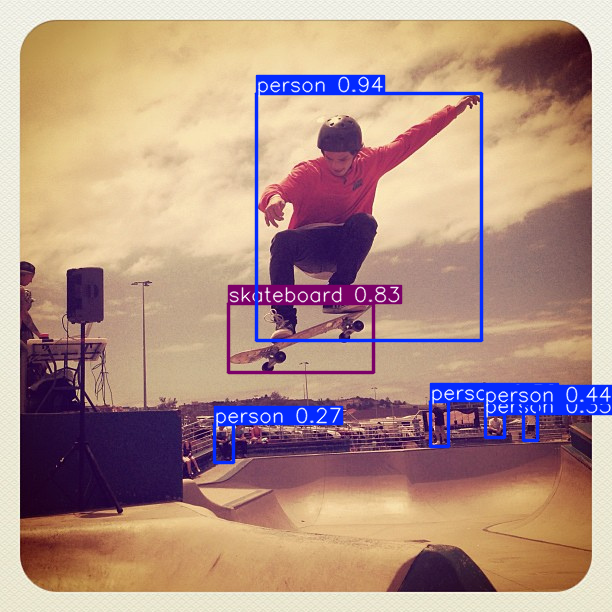

In [5]:
from ultralytics import YOLO
import cv2
from PIL import Image
from IPython.display import display

# 1. 파일 경로
image_path = "datasets/coco-dataset/images/val2017/000000581357.jpg"

# 2. 모델 로드
model = YOLO("yolo11n.pt")

# 3. Apple Silicon GPU(MPS) 추론 수행
results = model.predict(source=image_path, device="mps", conf=0.25)

# 4. 예측 결과 바운딩 박스가 그려진 이미지 획득 (OpenCV BGR 포맷 배열)
res_plotted = results[0].plot()

# 5. OpenCV의 BGR 포맷을 PIL 출력을 위해 RGB 포맷으로 채널 변환
res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

# 6. 주피터 노트북 셀 아래에 즉시 이미지 출력
display(Image.fromarray(res_rgb))


### 라벨링을 사진위에 그려보기

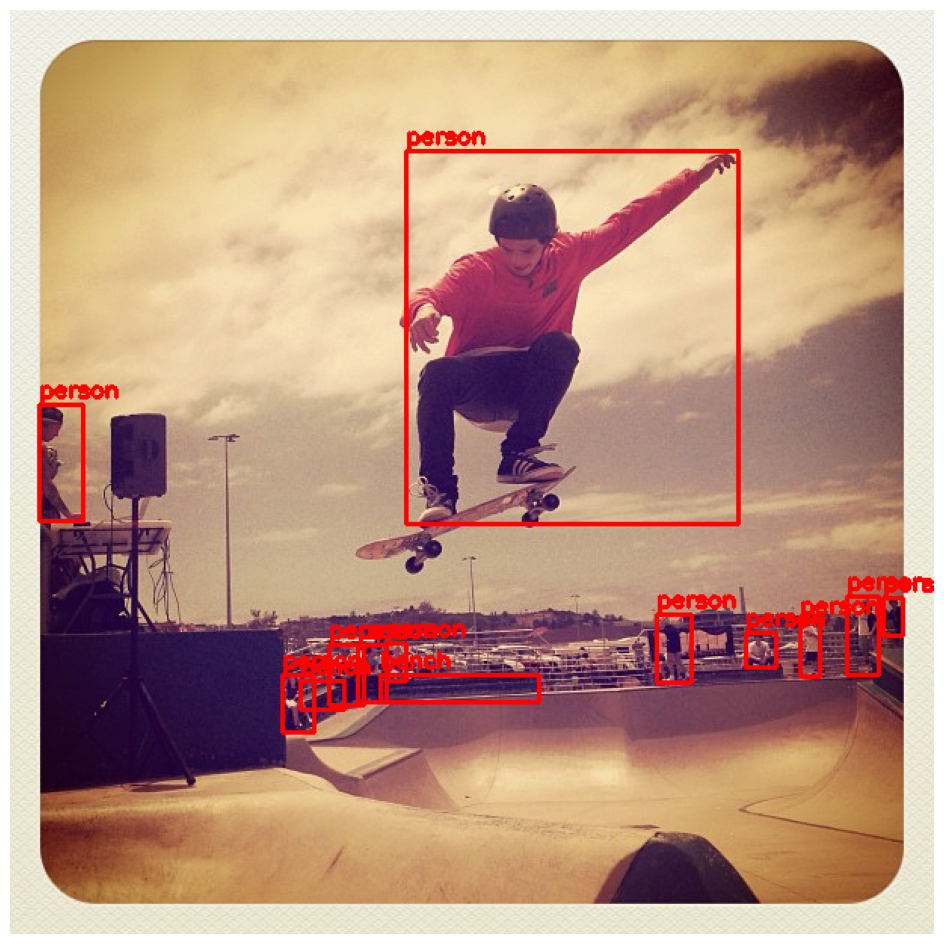

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. 파일 경로 설정
image_path = "datasets/coco-dataset/images/val2017/000000581357.jpg"
label_path = "datasets/coco-dataset/labels/val2017/000000581357.txt"

# 2. 이미 변환 완료된 12종 클래스 정의
class_names = {
    0: "person",
    1: "bicycle",
    2: "car",
    3: "motorcycle",
    4: "bus",
    5: "truck",
    6: "traffic light",
    7: "stop sign",
    8: "bench",
    9: "dog",
    10: "bollard",
    11: "kickboard"
}

# 3. 이미지 로드 및 해상도 획득
image = cv2.imread(image_path)
h_img, w_img, _ = image.shape

# 4. 라벨 파일 읽고 즉시 사각형 그리기
with open(label_path, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split()
        if not parts:
            continue
            
        # 0~11번 클래스 ID 그대로 읽기
        class_id = int(float(parts[0]))
        coords = [float(x) for x in parts[1:]]
        
        # 픽셀 절대 좌표 변환
        pts = []
        for i in range(0, len(coords), 2):
            px = int(coords[i] * w_img)
            py = int(coords[i+1] * h_img)
            pts.append([px, py])
            
        pts = np.array(pts, dtype=np.int32)
        
        # 최소/최대 좌표로 직사각형 경계 계산
        x_min, y_min = np.min(pts, axis=0)
        x_max, y_max = np.max(pts, axis=0)
        
        # 🔴 빨간색 바운딩 박스 그리기
        cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (0, 0, 255), 2)
        
        # 12종 클래스 이름 가져오기
        label_text = class_names.get(class_id, f"Class {class_id}")
        cv2.putText(image, label_text, (x_min, y_min - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

# 5. BGR ➡️ RGB 변환
res_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 6. 주피터 노트북 즉시 출력
plt.figure(figsize=(12, 12))
plt.imshow(res_rgb)
plt.axis("off")
plt.show()


### bollard-dataset의 기존 라벨 중 'tubular-marker-normal' 라벨은 사용하지 않을 것이므로 라벨 데이터 삭제 및 data.yaml 파일 수정

In [ ]:
import os
import yaml
from pathlib import Path

# 1. 파일 경로 설정
dataset_root = Path("./datasets/bollard-dataset")
label_splits = ["train/labels", "valid/labels", "test/labels"]

# 2. data.yaml 파일 직접 수정 (nc: 1, names: ['bollard'])

# 3. 라벨 파일 내에서 Class 1 라벨 삭제
total_modified_files = 0
total_removed_lines = 0

for split in label_splits:
    label_dir = dataset_root / split
    if not label_dir.exists():
        continue
        
    for txt_path in label_dir.glob("*.txt"):
        modified_lines = []
        has_tubular = False
        
        with open(txt_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                
                class_id = int(float(parts[0]))
                if class_id == 1:
                    # 1번 클래스 라벨 라인은 제외
                    has_tubular = True
                    total_removed_lines += 1
                else:
                    # 0번(bollard)만 유지
                    modified_lines.append(line.strip())
        
        # 실제 지워진 라벨이 있는 파일만 덮어쓰기
        if has_tubular:
            with open(txt_path, "w", encoding="utf-8") as f:
                if modified_lines:
                    f.write("\n".join(modified_lines) + "\n")
                else:
                    f.write("") # 모든 클래스가 지워진 경우 빈 파일로 둠
            total_modified_files += 1

print(f"🎉 완료: 총 {total_modified_files}개 라벨 파일 정제 (제거된 객체: {total_removed_lines}개)")


✅ data.yaml 수정 완료
🎉 완료: 총 0개 라벨 파일 정제 (제거된 객체: 0개)


### bollard-dataset의 0번 라벨을 10번으로 변경

In [ ]:
import os
import yaml
from pathlib import Path

# 1. 경로 설정 (bollard-dataset 루트 폴더)
dataset_root = Path("./datasets/bollard-dataset").resolve()
yaml_path = dataset_root / "data.yaml"
label_splits = ["train/labels", "valid/labels", "test/labels"]

print("=== 볼라드 데이터셋 0번 ➡️ 10번 인덱스 리매핑 시작 ===")

# 2. data.yaml 파일 수정 (names 정의를 10: bollard 구조로 변경)
if yaml_path.exists():
    try:
        with open(yaml_path, "r", encoding="utf-8") as f:
            data = yaml.safe_load(f)
        
        # nc는 11개로 확장 (0~10번 인덱스가 필요하므로)
        data["nc"] = 11
        # 리스트 구조 대신 딕셔너리 구조 {10: 'bollard'} 로 클래스 명시
        data["names"] = {10: "bollard"}
        
        with open(yaml_path, "w", encoding="utf-8") as f:
            yaml.dump(data, f, default_flow_style=False, sort_keys=False)
        print("✅ data.yaml 파일 수정 완료 (Class 10: bollard)")
    except Exception as e:
        print(f"⚠️ data.yaml 수정 중 에러 발생: {e}")
else:
    print("⚠️ data.yaml 파일을 찾을 수 없습니다.")

# 3. 각 라벨 파일에서 0번 ➡️ 10번 변환 진행
total_modified_files = 0
total_remapped_lines = 0

for split in label_splits:
    label_dir = dataset_root / split
    if not label_dir.exists():
        continue
        
    print(f"Processing split: {split}...")
    for txt_path in label_dir.glob("*.txt"):
        modified_lines = []
        is_modified = False
        
        with open(txt_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                
                class_id = int(float(parts[0]))
                if class_id == 0:
                    # 💡 0번을 10번으로 변경
                    parts[0] = "10"
                    is_modified = True
                    total_remapped_lines += 1
                
                modified_lines.append(" ".join(parts))
                
        # 변경이 일어난 파일에만 덮어쓰기 수행
        if is_modified:
            with open(txt_path, "w", encoding="utf-8") as f:
                f.write("\n".join(modified_lines) + "\n")
            total_modified_files += 1

print(f"\n🎉 완료: 총 {total_modified_files:,}개의 라벨 파일을 성공적으로 수정했습니다.")
print(f"   -> 10번으로 변환된 bollard 객체 수: {total_remapped_lines:,}개")

=== 볼라드 데이터셋 0번 ➡️ 10번 인덱스 리매핑 시작 ===
✅ data.yaml 파일 수정 완료 (Class 10: bollard)
Processing split: train/labels...
Processing split: valid/labels...
Processing split: test/labels...

🎉 완료: 총 1,640개의 라벨 파일을 성공적으로 수정했습니다.
   -> 10번으로 변환된 bollard 객체 수: 3,377개


### 원본 yolo11n.pt 모델로 bollard-dataset 객체탐지 후 우리 클래스에서 필요한 클래스만 뽑아서 클래스 인덱스 변환 후 기존 라벨링에 추가하기 및 bbox 형식으로 변환

In [12]:
import os
from pathlib import Path
from ultralytics import YOLO

# ==============================================================================
# [설정 정보] 데이터 경로 및 신뢰도 임계값을 설정하세요.
# ==============================================================================
# 볼라드 데이터셋 루트 경로
dataset_root = Path("./datasets/bollard-dataset").resolve()
label_splits = ["train", "valid", "test"] # 처리할 세부 데이터 스플릿

# 자동 라벨링을 수행할 사전 학습된 원본 YOLO11n 가중치 파일
model_path = "yolo11n.pt"

# 자동 라벨링 탐지 신뢰도 임계값 (너무 낮으면 오탐지가 덧붙여지므로 0.35~0.4 권장)
CONFIDENCE_THRESHOLD = 0.35

# ------------------------------------------------------------------------------
# 클래스 매핑 정의 (COCO 원본 ID ➡️ 우리 데이터셋 12종 중 0~9번 클래스 ID)
# ------------------------------------------------------------------------------
CLASS_MAP = {
    0: 0,   # person (보행자)
    1: 1,   # bicycle (자전거)
    2: 2,   # car (승용차)
    3: 3,   # motorcycle (오토바이)
    5: 4,   # bus (버스)
    7: 5,   # truck (트럭)
    9: 6,   # traffic light (신호등)
    11: 7,  # stop sign (정지 표지판)
    13: 8,  # bench (벤치)
    16: 9   # dog (반려견)
}

# 이미지 파일 확장자 정의
IMG_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

# ==============================================================================
# 오토 라벨링 실행
# ==============================================================================
def run_auto_labeling():
    # 1. 원본 YOLO11n 모델 로드
    if not os.path.exists(model_path):
        print(f"❌ 에러: {model_path} 가 중량 가중치 파일이 없습니다. 다운로드 받거나 경로를 확인하세요.")
        return
        
    model = YOLO(model_path)
    
    # GPU(MPS) 사용 가능 여부 확인
    import torch
    device = "mps" if torch.backends.mps.is_available() else "cpu"
    print(f"🚀 자동 라벨링 엔진 가동 (디바이스: {device})")

    for split in label_splits:
        img_dir = dataset_root / split / "images"
        lbl_dir = dataset_root / split / "labels"
        
        if not img_dir.exists():
            continue
            
        print(f"\nProcessing [{split}] split...")
        lbl_dir.mkdir(parents=True, exist_ok=True)
        
        count_processed = 0
        count_added_bboxes = 0
        
        # 스플릿 내부의 모든 이미지 탐색
        for img_path in img_dir.glob("*"):
            if img_path.suffix.lower() not in IMG_EXTS:
                continue
                
            stem = img_path.stem
            txt_path = lbl_dir / f"{stem}.txt"
            
            # 2. 이미지에 대해 YOLO11n 객체 탐지 수행
            # conf 옵션을 통해 신뢰도 조절
            results = model.predict(source=img_path, device=device, conf=CONFIDENCE_THRESHOLD, verbose=False)
            boxes = results[0].boxes
            
            new_labels_to_append = []
            
            for box in boxes:
                old_cls = int(box.cls[0].item())
                
                # 3. 우리가 필요로 하는 COCO 클래스(0~9번에 해당)인지 확인
                if old_cls in CLASS_MAP:
                    new_cls = CLASS_MAP[old_cls]
                    
                    # 4. YOLO 포맷 정규화 바운딩 박스 좌표 획득 [x_center, y_center, width, height]
                    xywhn = box.xywhn[0].tolist()
                    x_c, y_c, w, h = xywhn
                    
                    # 라벨 텍스트 라인 구성
                    label_line = f"{new_cls} {x_c:.6f} {y_c:.6f} {w:.6f} {h:.6f}"
                    new_labels_to_append.append(label_line)
            
            # 5. 기존 라벨 파일에 감지된 보도 관련 객체 정보 추가 (Append)
            if new_labels_to_append:
                # 'a' 모드로 열어서 기존의 볼라드(Class 10) 정보 밑에 이어서 쓰기
                # 만약 라벨 파일이 없던 새로운 이미지였다면 파일이 생성되어 쓰입니다.
                with open(txt_path, "a", encoding="utf-8") as f:
                    for new_lbl in new_labels_to_append:
                        f.write(new_lbl + "\n")
                
                count_added_bboxes += len(new_labels_to_append)
            
            count_processed += 1
            
        print(f"  -> 완료: 이미지 {count_processed}장 검사 완료")
        print(f"  -> 기존 라벨링에 자동 추가된 보행자/차량 등 객체 수: {count_added_bboxes}개")

if __name__ == "__main__":
    run_auto_labeling()


🚀 자동 라벨링 엔진 가동 (디바이스: mps)

Processing [train] split...
  -> 완료: 이미지 1610장 검사 완료
  -> 기존 라벨링에 자동 추가된 보행자/차량 등 객체 수: 3633개

Processing [valid] split...
  -> 완료: 이미지 81장 검사 완료
  -> 기존 라벨링에 자동 추가된 보행자/차량 등 객체 수: 40개

Processing [test] split...
  -> 완료: 이미지 1장 검사 완료
  -> 기존 라벨링에 자동 추가된 보행자/차량 등 객체 수: 2개


### kickboard-dataset의 person 라벨을 삭제 (yolo11n으로 어차피 다시 할것이기 때문), data.yaml도 수정

In [ ]:
import os
from pathlib import Path

# ==============================================================================
# 킥보드 데이터셋 경로
# ==============================================================================
dataset_root = Path("./datasets/kickboard-dataset").resolve()
label_splits = ["train/labels", "valid/labels", "test/labels"]

print("=== 킥보드 라벨 파일 0번(person) 클래스 삭제 시작 ===")

total_modified_files = 0
total_removed_person = 0

for split in label_splits:
    label_dir = dataset_root / split
    if not label_dir.exists():
        continue
        
    print(f"Processing split: {split}...")
    for txt_path in label_dir.glob("*.txt"):
        modified_lines = []
        has_person = False
        
        with open(txt_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                
                class_id = int(float(parts[0]))
                
                if class_id == 0:
                    # 💡 0번(person) 라벨은 완전히 제외
                    has_person = True
                    total_removed_person += 1
                else:
                    # 0번이 아닌 나머지 라벨(예: 1번)은 그대로 원본 유지
                    modified_lines.append(line.strip())
        
        # 실제 0번 라인이 제거된 파일에만 덮어쓰기 수행
        if has_person:
            with open(txt_path, "w", encoding="utf-8") as f:
                if modified_lines:
                    f.write("\n".join(modified_lines) + "\n")
                else:
                    # 모든 내용이 지워진 경우 빈 파일로 둠
                    f.write("")
            total_modified_files += 1

print(f"\n🎉 정제 완료: 총 {total_modified_files:,}개의 파일에서 0번 라벨이 제거되었습니다.")
print(f"   -> 제거된 person (Class 0) 객체 수: {total_removed_person:,}개")

=== 킥보드 라벨 파일 0번(person) 클래스 삭제 시작 ===
Processing split: train/labels...
Processing split: valid/labels...
Processing split: test/labels...

🎉 정제 완료: 총 312개의 파일에서 0번 라벨이 제거되었습니다.
   -> 제거된 person (Class 0) 객체 수: 532개


### kickboard-dataset의 1번 라벨을 11번으로 변경

In [14]:
import os
from pathlib import Path

# ==============================================================================
# [설정 정보] 킥보드 데이터셋 경로를 설정하세요.
# ==============================================================================
dataset_root = Path("./datasets/kickboard-dataset").resolve()
label_splits = ["train/labels", "valid/labels", "test/labels"]

print("=== 킥보드 라벨 파일 1번 ➡️ 11번 인덱스 변경 시작 ===")

total_modified_files = 0
total_remapped_lines = 0

for split in label_splits:
    label_dir = dataset_root / split
    if not label_dir.exists():
        continue
        
    print(f"Processing split: {split}...")
    for txt_path in label_dir.glob("*.txt"):
        modified_lines = []
        is_modified = False
        
        with open(txt_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                
                class_id = int(float(parts[0]))
                
                if class_id == 1:
                    # 💡 1번을 11번으로 변경
                    parts[0] = "11"
                    is_modified = True
                    total_remapped_lines += 1
                
                modified_lines.append(" ".join(parts))
        
        # 변경 사항이 발생한 파일에만 덮어쓰기 수행
        if is_modified:
            with open(txt_path, "w", encoding="utf-8") as f:
                f.write("\n".join(modified_lines) + "\n")
            total_modified_files += 1

print(f"\n🎉 완료: 총 {total_modified_files:,}개의 라벨 파일을 성공적으로 수정했습니다.")
print(f"   -> 11번으로 변환된 kickboard 객체 수: {total_remapped_lines:,}개")


=== 킥보드 라벨 파일 1번 ➡️ 11번 인덱스 변경 시작 ===
Processing split: train/labels...
Processing split: valid/labels...
Processing split: test/labels...

🎉 완료: 총 2,503개의 라벨 파일을 성공적으로 수정했습니다.
   -> 11번으로 변환된 kickboard 객체 수: 3,172개


원본 yolo11n.pt 모델로 kickboard-dataset 객체탐지 후 우리 클래스에서 필요한 클래스만 뽑아서 클래스 인덱스 변환 후 기존 라벨링에 추가하기 및 bbox 형식으로 변환

In [15]:
import os
from pathlib import Path
from ultralytics import YOLO

# ==============================================================================
# 데이터셋 경로 및 신뢰도 임계값
# ==============================================================================
# 대상 킥보드 데이터셋 루트 경로
dataset_root = Path("./datasets/kickboard-dataset").resolve()
label_splits = ["train", "valid", "test"] # 순회할 데이터 스플릿

# 자동 감지 임계값 (0.35 ~ 0.4 추천 - 오탐지 최소화 목적)
CONFIDENCE_THRESHOLD = 0.35

# ------------------------------------------------------------------------------
# 클래스 매핑 정의 (COCO 원본 ID ➡️ 우리 데이터셋 12종 중 0~9번 클래스 ID)
# ------------------------------------------------------------------------------
CLASS_MAP = {
    0: 0,   # person (보행자)
    1: 1,   # bicycle (자전거)
    2: 2,   # car (승용차)
    3: 3,   # motorcycle (오토바이)
    5: 4,   # bus (버스)
    7: 5,   # truck (트럭)
    9: 6,   # traffic light (신호등)
    11: 7,  # stop sign (정지 표지판)
    13: 8,  # bench (벤치)
    16: 9   # dog (반려견)
}

# 이미지 확장자 종류
IMG_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

# ==============================================================================
# Auto-Labeling 실행 함수
# ==============================================================================
def run_kickboard_auto_labeling():

    # 1. 모델 파일 확인 및 로드        
    model = YOLO("yolo11n.pt")
    
    # Apple Silicon GPU 가속 확인
    import torch
    device = "mps" if torch.backends.mps.is_available() else "cpu"
    print(f"🚀 자동 라벨링 시작 (디바이스: {device})")

    for split in label_splits:
        img_dir = dataset_root / split / "images"
        lbl_dir = dataset_root / split / "labels"
        
        if not img_dir.exists():
            continue
            
        print(f"\nProcessing [{split}] split...")
        lbl_dir.mkdir(parents=True, exist_ok=True)
        
        count_processed = 0
        count_added_bboxes = 0
        
        # 스플릿 내 모든 이미지에 대해 루프
        for img_path in img_dir.glob("*"):
            if img_path.suffix.lower() not in IMG_EXTS:
                continue
                
            stem = img_path.stem
            txt_path = lbl_dir / f"{stem}.txt"
            
            # 2. YOLO11n으로 이미지 추론 수행
            results = model.predict(source=img_path, device=device, conf=CONFIDENCE_THRESHOLD, verbose=False)
            boxes = results[0].boxes
            
            new_labels_to_append = []
            
            for box in boxes:
                old_cls = int(box.cls[0].item())
                
                # 3. 보행 환경용 10대 클래스에 포함되는지 체크
                if old_cls in CLASS_MAP:
                    new_cls = CLASS_MAP[old_cls]
                    
                    # 4. YOLO 규격화 좌표 복원 [x_center, y_center, width, height]
                    xywhn = box.xywhn[0].tolist()
                    x_c, y_c, w, h = xywhn
                    
                    label_line = f"{new_cls} {x_c:.6f} {y_c:.6f} {w:.6f} {h:.6f}"
                    new_labels_to_append.append(label_line)
            
            # 5. 기존의 킥보드 라벨(Class 11) 파일 끝부분에 덧붙이기 (Append)
            if new_labels_to_append:
                # 'a' 모드로 열어 기존 파일 내용 보존 후 하단에 한 줄씩 이어서 씀
                with open(txt_path, "a", encoding="utf-8") as f:
                    for new_lbl in new_labels_to_append:
                        f.write(new_lbl + "\n")
                
                count_added_bboxes += len(new_labels_to_append)
            
            count_processed += 1
            
        print(f"  -> {split} 분할 완료: 이미지 {count_processed}장 추론 완료")
        print(f"  -> 기존 라벨(Class 11) 외 추가된 보행자/차량 등 객체 수: {count_added_bboxes}개")

if __name__ == "__main__":
    run_kickboard_auto_labeling()


🚀 자동 라벨링 시작 (디바이스: mps)

Processing [train] split...
  -> train 분할 완료: 이미지 2185장 추론 완료
  -> 기존 라벨(Class 11) 외 추가된 보행자/차량 등 객체 수: 1855개

Processing [valid] split...
  -> valid 분할 완료: 이미지 215장 추론 완료
  -> 기존 라벨(Class 11) 외 추가된 보행자/차량 등 객체 수: 157개

Processing [test] split...
  -> test 분할 완료: 이미지 107장 추론 완료
  -> 기존 라벨(Class 11) 외 추가된 보행자/차량 등 객체 수: 114개


# YOLO11n 모델 순차 학습 제안
- 1번째 학습 데이터: coco-dataset(10개 라벨링만 먼저 학습; 해당 데이터에는 bollard와 kickboard가 라벨링되어있지 않기 때문에 먼저 학습)
- 2번째 학습 데이터: kickboard-dataset, bollard-dataset을 통합한 데이터셋을 구축(kickboard-dataset에는 bollard 라벨링이, bollard-dataset에는 kickboard 라벨링 데이터가 없어서 통합된 데이터셋으로 함)

그럼에도 불구하고...

### kickboard/bollard-dataset에 오토 라벨링을 적용했음에도 순차 학습이 위험한 이유

#### ① '망각'과 '과적합'
*   **문제**: 2단계 학습 시 모델은 오직 4,800장의 이미지 속 보행자, 차량, 볼라드, 킥보드만 보며 학습하게 됩니다.
*   **결과**: 아무리 4,800장 안에 보행자/차량이 라벨링되어 있어도, 모델은 이 4,800장의 촬영 환경(특정 구도, 날씨, 카메라 렌즈 화각 등)에 과적합됩니다. 이 과정에서 1단계에서 학습했던 COCO 3만 장 기반의 범용적인 특징들을 잃어버리게 되어, 다른 일반 도로 환경에서의 보행자/차량 인식 성능이 대폭 감소합니다.

#### ② 오토 라벨링 노이즈(오차)의 누적 학습
*   원본 YOLO11n 모델이 4,800장의 사진 속에서 수행한 오토 라벨링이 100% 완벽할 수는 없습니다. 멀리 있거나 가려진 보행자를 놓쳤을 수도 있고, 다른 사물을 차량으로 오인했을 수도 있습니다.
*   2단계 학습 시 이 오염된 라벨링 정보를 집중적으로 학습하게 되므로, 기존 1단계에서 정교하게 다듬어 놓은 0~9번 클래스의 감지 정확도가 오히려 떨어지는 역효과가 발생할 수 있습니다.

---

### 권장하는 최적의 학습 전략

#### 💡 추천 전략 : 단일 통합 학습
*   **방법**: COCO 10종 정제 데이터셋(약 3만 장)과 오토 라벨링이 완료된 킥보드/볼라드 데이터셋(약 4,800장)을 **전부 한 폴더에 섞은 뒤, 처음부터 `yolo11n.pt`를 불러와 1회만 학습**시킵니다.
*   **이유**: 굳이 1단계 학습을 따로 나눌 필요가 없습니다. 어차피 `yolo11n.pt`는 이미 COCO의 수십만 장 데이터로 사전 학습(Pre-trained)되어 있으므로 기본 뼈대가 튼튼합니다. 이를 바탕으로 3만 4천여 장의 통합 데이터셋을 한 번에 학습시키는 것이 학습 안정성과 최종 정확도 모두 극대화됩니다.

이러한 LLM의 제안에 따라 통합 데이터셋을 구축하여 추천 전략(단일 통합 학습)을 진행하기로 결정하였다.

모델의 성능을 정확하게 측정하려면 검증(Validation) 및 테스트(Test) 데이터셋 내 모든 이미지에 12개 클래스가 완벽하게 라벨링되어 있어야 한다.

하지만 본 프로젝트에서는 시간적 한계로 인해, 전체 통합 데이터셋을 무작위(Random)로 분할하여 검증 및 테스트를 진행하기로 한다. 이 방식의 특성상 다음과 같은 한계가 존재함을 미리 밝혀둔다.

- 라벨 누락으로 인한 지표 왜곡: 무작위로 분할된 Val/Test 데이터셋 중 상당수는 기존 COCO 데이터셋에서 온 이미지들이다. 이 이미지들에는 볼라드(bollard)나 킥보드(kickboard)가 라벨링되어 있지 않다. 따라서 모델이 실제 사진 속 볼라드나 킥보드를 똑바로 감지해내더라도, 정답지(Label)가 없어 오탐(False Positive)으로 처리되어 평가지표(mAP)가 실제 성능보다 낮게 나올 확률이 높다.
- 평가의 불균형: 전체 검증 데이터 중 COCO 이미지의 비중이 훨씬 크기 때문에, 새로 추가된 볼라드와 킥보드 클래스의 객관적인 검출 성능을 완벽히 대변하기는 어렵다.

결론적으로, 이번 학습 결과로 도출되는 수치상 성능 지표는 실제 모델의 탐지 성능보다 다소 과소평가되어 나타날 수 있음을 인정하며, 이를 감안하여 결과를 해석해야 한다.

# 통합 데이터셋 구축 및 랜덤 분할 코드
- 데이터셋 폴더 구조 구축
- 데이터셋 랜덤 분할(train-test-split)

In [17]:
import os
import shutil
import yaml
from pathlib import Path
from sklearn.model_selection import train_test_split

# ==============================================================================
# 1. 경로 설정
# ==============================================================================
# 현재 작업 디렉토리 기준 datasets 폴더 경로 지정
DATASET_DIR = Path("./datasets").resolve()
OUTPUT_DIR = DATASET_DIR / "coco_total"  # 최종적으로 합쳐질 폴더

# 원본 데이터셋 경로
COCO_DIR = DATASET_DIR / "coco-dataset"
BOLLARD_DIR = DATASET_DIR / "bollard-dataset"
KICKBOARD_DIR = DATASET_DIR / "kickboard-dataset"

# 허용할 이미지 확장자 목록
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# ==============================================================================
# 2. 이미지-라벨 매칭 파일 수집 함수
# ==============================================================================
def collect_image_label_pairs(img_root, lbl_root, prefix):
    pairs = []
    if not img_root.exists() or not lbl_root.exists():
        print(f"⚠️ 경로 없음 경고: {img_root} 또는 {lbl_root}가 존재하지 않습니다.")
        return pairs
    
    # 이미지 폴더를 순회하며 확장자 매칭 파일 찾기
    for img_path in img_root.glob("**/*"):
        if img_path.suffix.lower() not in IMG_EXTS:
            continue
        
        # 이미지의 상대 경로를 이용해 동일한 이름의 라벨(.txt) 파일 매칭
        relative_path = img_path.relative_to(img_root)
        lbl_path = lbl_root / relative_path.with_suffix(".txt")
        
        if lbl_path.exists():
            pairs.append({
                "img": img_path,
                "lbl": lbl_path,
                "prefix": prefix
            })
    
    print(f"🔍 {prefix[:-1]} 데이터셋 수집 완료: {len(pairs)}장")
    return pairs

# ==============================================================================
# 3. 모든 데이터 수집 실행
# ==============================================================================
print("=== 데이터셋 수집 시작 ===")
all_pairs = []

# (1) COCO 데이터 수집
all_pairs.extend(collect_image_label_pairs(COCO_DIR / "images/train2017", COCO_DIR / "labels/train2017", "coco_"))
all_pairs.extend(collect_image_label_pairs(COCO_DIR / "images/val2017", COCO_DIR / "labels/val2017", "coco_"))

# (2) 볼라드 데이터 수집
all_pairs.extend(collect_image_label_pairs(BOLLARD_DIR / "train/images", BOLLARD_DIR / "train/labels", "bollard_"))
all_pairs.extend(collect_image_label_pairs(BOLLARD_DIR / "valid/images", BOLLARD_DIR / "valid/labels", "bollard_"))
all_pairs.extend(collect_image_label_pairs(BOLLARD_DIR / "test/images", BOLLARD_DIR / "test/labels", "bollard_"))

# (3) 킥보드 데이터 수집
all_pairs.extend(collect_image_label_pairs(KICKBOARD_DIR / "train/images", KICKBOARD_DIR / "train/labels", "kickboard_"))
all_pairs.extend(collect_image_label_pairs(KICKBOARD_DIR / "valid/images", KICKBOARD_DIR / "valid/labels", "kickboard_"))
all_pairs.extend(collect_image_label_pairs(KICKBOARD_DIR / "test/images", KICKBOARD_DIR / "test/labels", "kickboard_"))

total_count = len(all_pairs)
print(f"📊 총 수집된 통합 이미지-라벨 페어: {total_count:,}장\n")

if total_count == 0:
    raise ValueError("❌ 수집된 데이터 페어가 없습니다. 데이터셋 폴더 경로를 다시 확인해주세요.")

# ==============================================================================
# 4. sklearn.model_selection.train_test_split를 이용한 랜덤 분할
# ==============================================================================
# 전체 대비 80%를 Train, 20%를 임시(Val+Test) 데이터셋으로 분할
train_pairs, temp_pairs = train_test_split(all_pairs, test_size=0.2, random_state=42, shuffle=True)

# 남은 20% 임시 데이터셋을 절반(50%)으로 나눠 Val(10%), Test(10%)로 최종 분할
val_pairs, test_pairs = train_test_split(temp_pairs, test_size=0.5, random_state=42, shuffle=True)

print("=== 데이터셋 분할 완료 ===")
print(f"   - Train (80%): {len(train_pairs):,}장")
print(f"   - Val   (10%): {len(val_pairs):,}장")
print(f"   - Test  (10%): {len(test_pairs):,}장\n")

# ==============================================================================
# 5. 지정 폴더에 데이터 복사 진행
# ==============================================================================
splits = {
    "train": train_pairs,
    "val": val_pairs,
    "test": test_pairs
}

print("=== 파일 복사 시작 (파일명 중복 방지 접두사 적용) ===")
for split_name, pairs in splits.items():
    dest_img_dir = OUTPUT_DIR / "images" / split_name
    dest_lbl_dir = OUTPUT_DIR / "labels" / split_name
    
    # 목적지 폴더 생성
    dest_img_dir.mkdir(parents=True, exist_ok=True)
    dest_lbl_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"➡️ [{split_name}] 폴더로 복사 중...")
    for pair in pairs:
        src_img = pair["img"]
        src_lbl = pair["lbl"]
        prefix = pair["prefix"]
        
        # 파일 중복 방지를 위해 접두사 추가
        new_img_name = prefix + src_img.name
        new_lbl_name = prefix + src_lbl.name
        
        # 복사 실행
        shutil.copy2(src_img, dest_img_dir / new_img_name)
        shutil.copy2(src_lbl, dest_lbl_dir / new_lbl_name)

print("\n🎉 모든 파일이 성공적으로 복사되었습니다!")

# ==============================================================================
# 6. data.yaml 설정 파일 생성
# ==============================================================================
data_yaml = {
    "path": str(OUTPUT_DIR),  # 절대 경로로 지정하여 학습 시 경로 오류 방지
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {
        0: "person",
        1: "bicycle",
        2: "car",
        3: "motorcycle",
        4: "bus",
        5: "truck",
        6: "traffic light",
        7: "stop sign",
        8: "bench",
        9: "dog",
        10: "bollard",
        11: "kickboard"
    }
}

yaml_path = OUTPUT_DIR / "data.yaml"
with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print(f"📝 학습용 설정 파일(data.yaml) 생성 완료: {yaml_path}")


=== 데이터셋 수집 시작 ===
🔍 coco 데이터셋 수집 완료: 29419장
🔍 coco 데이터셋 수집 완료: 1265장
🔍 bollard 데이터셋 수집 완료: 1610장
🔍 bollard 데이터셋 수집 완료: 81장
🔍 bollard 데이터셋 수집 완료: 1장
🔍 kickboard 데이터셋 수집 완료: 2185장
🔍 kickboard 데이터셋 수집 완료: 215장
🔍 kickboard 데이터셋 수집 완료: 107장
📊 총 수집된 통합 이미지-라벨 페어: 34,883장

=== 데이터셋 분할 완료 ===
   - Train (80%): 27,906장
   - Val   (10%): 3,488장
   - Test  (10%): 3,489장

=== 파일 복사 시작 (파일명 중복 방지 접두사 적용) ===
➡️ [train] 폴더로 복사 중...
➡️ [val] 폴더로 복사 중...
➡️ [test] 폴더로 복사 중...

🎉 모든 파일이 성공적으로 복사되었습니다!
📝 학습용 설정 파일(data.yaml) 생성 완료: /Users/company/Downloads/drive-download-20260617T184243Z-3-001/datasets/coco_total/data.yaml


MAC Mini M4 16Gb 라는 하드웨어에서 시간 및 메모리적으로 가용한 YOLO11n 모델 학습을 위한 다양한 하이퍼파라미터 조합

# 📊 YOLO11n 하이퍼파라미터 비교 실험 설계 (Experiment Design)

본 실험은 한국 보도 환경 특화 객체 탐지 모델의 성능을 극대화하기 위해, **M4 Mac Mini (16GB RAM) 하드웨어 환경**에 맞춰 설계된 하이퍼파라미터 비교 실험 그리드입니다. 20 Epoch 동안의 짧은 학습을 진행하여 추이를 비교한 뒤 최종 모델 학습용 매개변수를 선정합니다.

---

## 1. 하이퍼파라미터 실험 설정 비교표

| 하이퍼파라미터 | YOLO11 디폴트값 | 실험 1 (Baseline) | 실험 2 (Optimizer & LR) | 실험 3 (Heavy Augmentation) |
| :--- | :---: | :---: | :---: | :---: |
| **`optimizer`** | `auto` | `auto` | **`AdamW`** | **`AdamW`** |
| **`cos_lr`** | `False` | `False` | **`True`** | **`True`** |
| **`lr0`** (초기 학습률) | `0.01` | `0.01` | **`0.001`** | **`0.001`** |
| **`batch`** (배치 크기) | `16` | **`32`** | **`32`** | **`32`** |
| **`mixup`** (데이터 증강) | `0.0` | `0.0` | `0.0` | **`0.15`** |
| **`hsv_v`** (밝기 변화) | `0.4` | `0.4` | `0.4` | **`0.4`** (기본값 유지) |
| **`cache`** (메모리 캐싱) | `False` | **`True`** | **`True`** | **`True`** |
| **`epochs`** (학습 세대) | `100` | **`20`** | **`20`** | **`20`** |
| **`imgsz`** (이미지 크기) | `640` | `640` | `640` | `640` |

---

## 2. 실험 그룹별 목적 및 특이사항

### 🧪 실험 1 : Baseline (기준점 설정)
* **목적**: 공식 가이드라인의 기본 하이퍼파라미터를 사용하여 최적화의 기준이 되는 베이스라인 성능을 측정합니다.
* **특이사항**:
  * `optimizer='auto'` 설정으로 모델 규모와 하드웨어에 따라 최적의 옵티마이저를 자동으로 선택합니다.
  * 학습률이 선형(Linear)으로 감소하는 기본 스케줄러를 사용합니다.

### 🧪 실험 2 : Optimizer & LR (최적화 스케줄러 세밀화)
* **목적**: 경사하강법 최적화 도구와 학습률 스케줄러를 튜닝하여 보다 안정적이고 미세한 가중치 수렴을 유도합니다.
* **특이사항**:
  * 파인튜닝 시 안정적이라고 평가받는 **`AdamW`**를 수동 지정하고, 초기 학습률(`lr0`)을 기본값인 `0.01`에서 **`0.001`**로 낮춰 전이 학습 시 기존 가중치가 급격히 훼손되는 것을 방지합니다.
  * **`cos_lr=True`** 설정을 통해 학습이 후반부로 갈수록 학습률이 부드러운 곡선(Cosine)을 그리며 감소하도록 만들어 최고 성능을 유도합니다.

### 🧪 실험 3 : Heavy Augmentation (소수 클래스 보강 및 실외 환경 최적화)
* **목적**: 킥보드, 볼라드와 같은 **소수 클래스의 데이터 부족 및 과적합 문제를 완화**하고, 다양한 야외 조도에 강건한 모델을 만듭니다.
* **특이사항**:
  * **`mixup=0.15`**를 적용하여 두 이미지를 오버랩하는 데이터 증강 기술을 활성화합니다. 이를 통해 소수 객체가 복잡한 배경에 묻혀 과적합되는 현상을 억제합니다.
  * **`hsv_v=0.4`**(HSV 밝기 조정폭)를 활성화하여 주간 그늘진 곳, 역광, 일몰 등 시시각각 변하는 한국 도로 환경의 명암 변화에 유연하게 대응합니다.

---

## 3. M4 Mac Mini (16GB RAM) 하드웨어 최적화 가이드

이번 실험 코드는 M4 Mac Mini의 아키텍처 특성을 고려하여 아래와 같이 성능 가속 옵션을 기본 적용하였습니다.

* **`device="mps"` (Metal Performance Shaders)**
  * 애플 M4 칩의 내장 GPU 가속을 활용합니다. CPU 학습 대비 수십 배 이상 빠른 연산 속도를 보장합니다.
* **`batch=32` (배치 크기 상향)**
  * 가벼운 YOLO11n 모델의 특성상 배치 크기를 `16`에서 `32`로 올리면 GPU의 병렬 처리 유닛 사용률이 극대화되어 학습 시간이 단축됩니다.

In [1]:
import os
from ultralytics import YOLO

# 실험 디자인
experiments = [
    {
        "name": "baseline",
        "params": {
            "optimizer": "auto",
            "cos_lr": False,
            "mixup": 0.0,
            "patience": 0,
        }
    },
    {
        "name": "adamw_cos",
        "params": {
            "optimizer": "AdamW",
            "cos_lr": True,
            "lr0": 0.001,
            "patience": 0,
        }
    },
    {
        "name": "heavy_aug",
        "params": {
            "optimizer": "AdamW",
            "cos_lr": True,
            "lr0": 0.001,
            "mixup": 0.15,
            "hsv_v": 0.4,
            "patience": 0,
        }
    }
]

# 학습 실행
for exp in experiments:
    print(f"\n" + "="*50)
    print(f"🚀 실험 시작: {exp['name']}")
    print("="*50)
    
    model = YOLO("yolo11n.pt")
    
    model.train(
        data="datasets/coco_total/data.yaml",
        epochs=20,
        batch=16,
        device="mps",
        project="exp_comparison",  
        name=exp["name"],
        **exp["params"]
    )
    
print("\n🎉 모든 하이퍼파라미터 비교 실험이 완료되었습니다!")



🚀 실험 시작: baseline
New https://pypi.org/project/ultralytics/8.4.71 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.70 🚀 Python-3.14.3 torch-2.12.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/coco_total/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bas

# 📊 각 실험별 best.pt 기준 성능 비교표

In [11]:
import pandas as pd
import glob
from pathlib import Path

# 1. 실험 결과 파일 수집
results_paths = glob.glob("exp_comparison/*/results.csv")
summary_data = []

if not results_paths:
    print("❌ 실험 결과 파일(results.csv)을 찾을 수 없습니다. 모든 학습이 완료된 후 실행해주세요.")
else:
    for path in results_paths:
        exp_name = Path(path).parent.name
        df = pd.read_csv(path)
        
        # 컬럼 이름의 공백 제거
        df.columns = [c.strip() for c in df.columns]
        
        # 버전 호환성을 위한 컬럼명 동적 탐색
        map50_col = [c for c in df.columns if 'mAP50(B)' in c][0]
        map95_col = [c for c in df.columns if 'mAP50-95(B)' in c][0]
        train_loss_col = [c for c in df.columns if 'train/box_loss' in c][0]
        val_loss_col = [c for c in df.columns if 'val/box_loss' in c][0]
        
        # 💡 [보완] YOLO 공식 Fitness 공식 추가 (best.pt가 저장되는 실제 기준)
        # Fitness = 10%의 mAP50 + 90%의 mAP50-95
        df['fitness'] = 0.1 * df[map50_col] + 0.9 * df[map95_col]
        
        # Fitness가 가장 높은 행(즉, 실제 best.pt로 저장된 Epoch)을 찾음
        best_row = df.loc[df['fitness'].idxmax()]
        
        summary_data.append({
            "실험명": exp_name,
            "Best Epoch (best.pt)": int(best_row['epoch']),
            "mAP50 (Box)": round(best_row[map50_col], 4),
            "mAP50-95 (Box)": round(best_row[map95_col], 4),
            "Train Box Loss": round(best_row[train_loss_col], 4),
            "Val Box Loss": round(best_row[val_loss_col], 4) if val_loss_col in best_row else "N/A"
        })

    # 데이터프레임 변환 및 마크다운 출력
    summary_df = pd.DataFrame(summary_data)
    print("\n📊 [각 실험별 best.pt 기준 성능 비교표]")
    print(summary_df.to_markdown(index=False))



📊 [각 실험별 best.pt 기준 성능 비교표]
| 실험명    |   Best Epoch (best.pt) |   mAP50 (Box) |   mAP50-95 (Box) |   Train Box Loss |   Val Box Loss |
|:----------|-----------------------:|--------------:|-----------------:|-----------------:|---------------:|
| heavy_aug |                     20 |        0.6638 |           0.462  |           1.1914 |         1.1934 |
| baseline  |                     20 |        0.6772 |           0.4768 |           1.1652 |         1.1662 |
| adamw_cos |                     20 |        0.6654 |           0.4638 |           1.1904 |         1.1892 |


# 📈 실험별 Epoch에 따른 성능 그래프

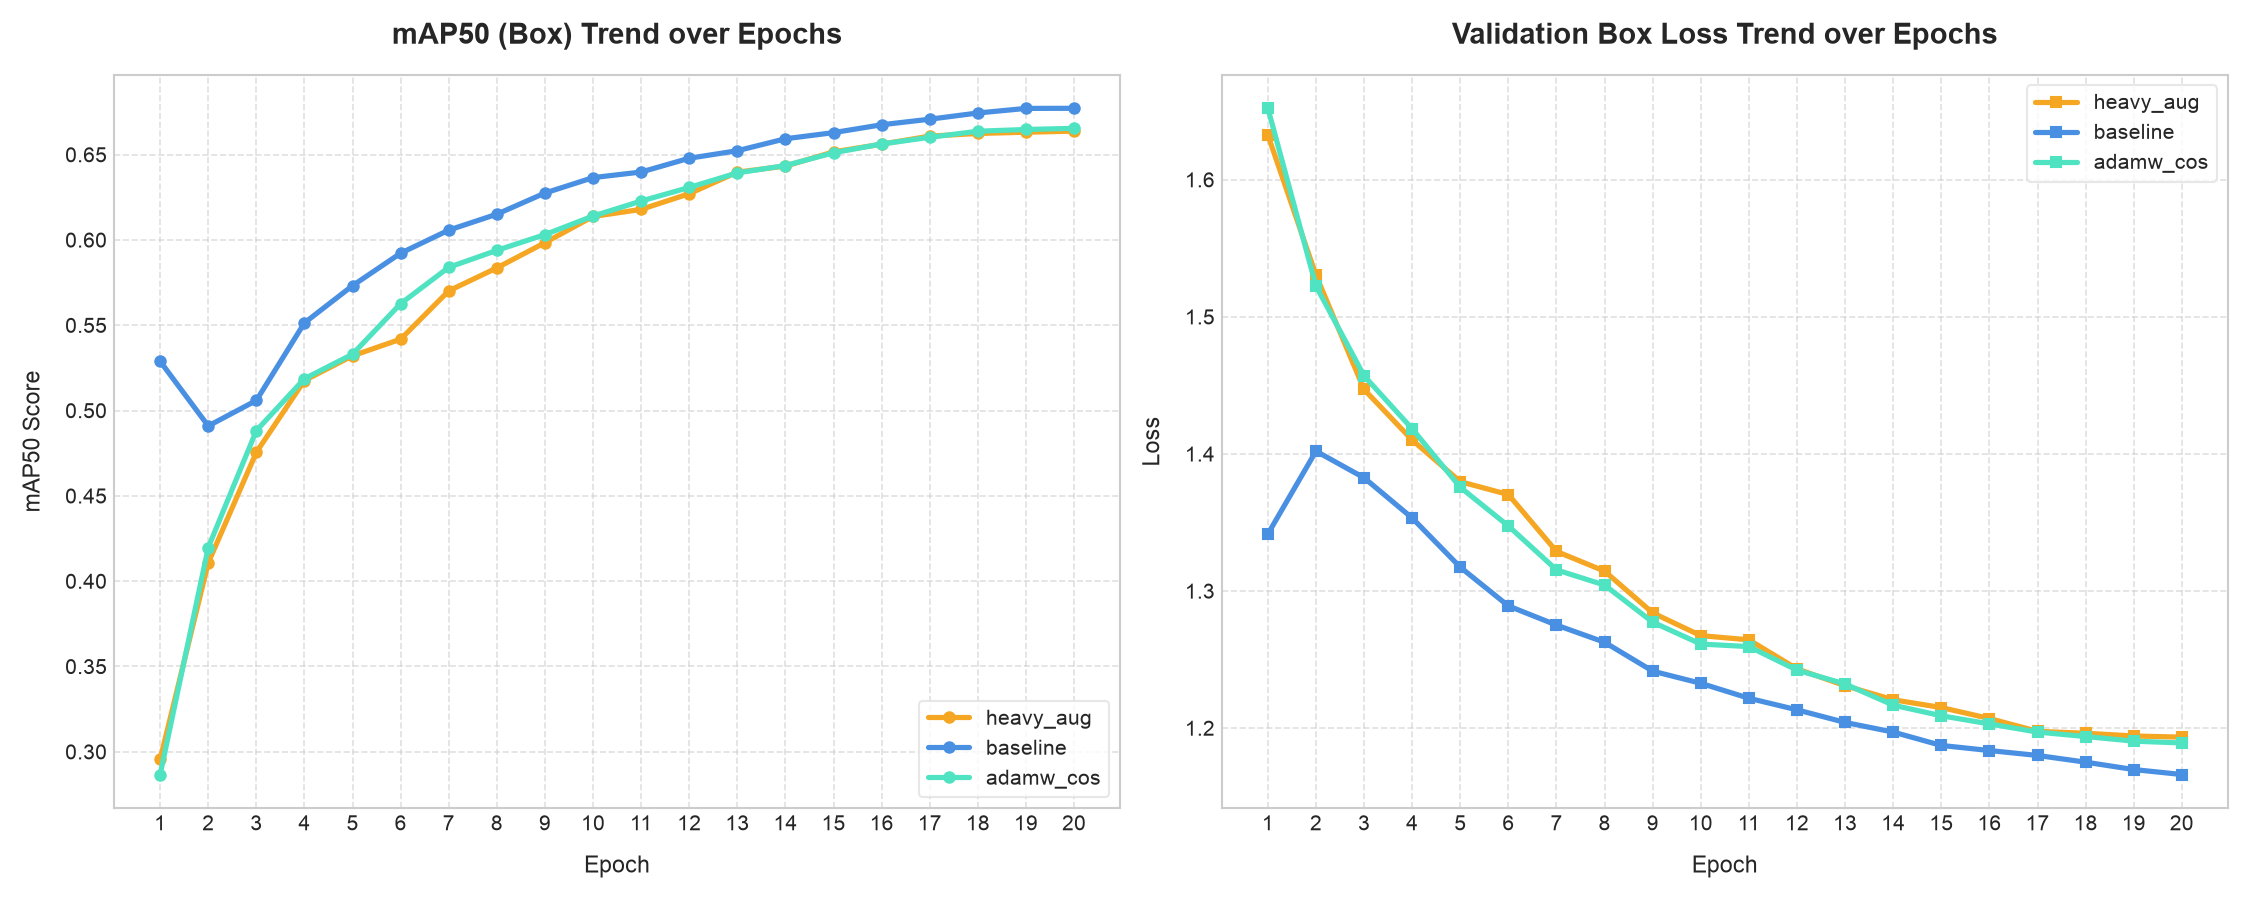

In [12]:
# 1. 주피터 노트북 인라인 그래픽 활성화 매직 명령어
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import glob
from pathlib import Path
from IPython.display import Image, display  # 👈 이미지를 강제로 화면에 띄우기 위한 라이브러리

# ==============================================================================
# 2. 그래프 스타일링 설정
# ==============================================================================
plt.rcParams['axes.unicode_minus'] = False   
plt.style.use('seaborn-v0_8-whitegrid')      

# ==============================================================================
# 3. 결과 파일 경로 수집
# ==============================================================================
results_paths = glob.glob("exp_comparison/*/results.csv")

if not results_paths:
    print("❌ 실험 결과 파일(results.csv)을 찾을 수 없습니다. 학습이 완료된 후 실행해주세요.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=150)
    
    colors = {
        "baseline": "#4A90E2",   
        "adamw_cos": "#50E3C2",  
        "heavy_aug": "#F5A623"   
    }

    # ==============================================================================
    # 4. CSV 데이터 로드 및 시각화
    # ==============================================================================
    for path in results_paths:
        exp_name = Path(path).parent.name
        df = pd.read_csv(path)
        
        df.columns = [c.strip() for c in df.columns]
        epochs = df['epoch']
        
        map50_col = [c for c in df.columns if 'mAP50(B)' in c][0]
        val_loss_col = [c for c in df.columns if 'val/box_loss' in c][0]
        
        color = colors.get(exp_name, "#9B9B9B")
        
        # [좌측 그래프] Epoch별 mAP50 변화 그리기
        axes[0].plot(
            epochs, df[map50_col], 
            label=exp_name, 
            marker='o', 
            color=color, 
            linewidth=2.5, 
            markersize=5
        )
        
        # [우측 그래프] Epoch별 Validation Box Loss 변화 그리기
        axes[1].plot(
            epochs, df[val_loss_col], 
            label=exp_name, 
            marker='s', 
            color=color, 
            linewidth=2.5, 
            markersize=5
        )

    # ==============================================================================
    # 5. 그래프 디테일 꾸미기 (영문 적용)
    # ==============================================================================
    axes[0].set_title("mAP50 (Box) Trend over Epochs", fontsize=14, fontweight='bold', pad=15)
    axes[0].set_xlabel("Epoch", fontsize=11, labelpad=10)
    axes[0].set_ylabel("mAP50 Score", fontsize=11, labelpad=10)
    axes[0].set_xticks(range(1, 21))
    axes[0].legend(frameon=True, facecolor='white', edgecolor='#e2e2e2', fontsize=10, loc='lower right')
    axes[0].grid(True, linestyle='--', alpha=0.6)

    axes[1].set_title("Validation Box Loss Trend over Epochs", fontsize=14, fontweight='bold', pad=15)
    axes[1].set_xlabel("Epoch", fontsize=11, labelpad=10)
    axes[1].set_ylabel("Loss", fontsize=11, labelpad=10)
    axes[1].set_xticks(range(1, 21))
    axes[1].legend(frameon=True, facecolor='white', edgecolor='#e2e2e2', fontsize=10, loc='upper right')
    axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    
    # ==============================================================================
    # 6. [해결 핵심] 이미지 파일로 저장한 뒤 강제 출력하기
    # ==============================================================================
    plot_path = "comparison_plot.png"
    plt.savefig(plot_path, dpi=150)  # 그래프를 파일로 저장
    plt.close()                      # matplotlib 백엔드 세션 초기화
    
    # 저장한 이미지 파일을 주피터 노트북에 강제로 출력
    display(Image(filename=plot_path))


In [ ]:
import glob
import yaml
import pandas as pd
from pathlib import Path

# 1. exp_comparison 폴더 하위의 모든 args.yaml 파일 검색
args_paths = glob.glob("exp_comparison/*/args.yaml")

# 2. 비교 분석할 핵심 하이퍼파라미터 목록 정의
target_params = [
    "optimizer",  # 옵티마이저 (auto, AdamW 등)
    "lr0",        # 초기 학습률
    "cos_lr",     # 코사인 스케줄러 적용 여부 (True/False)
    "mixup",      # 믹스업 이미지 증강 비율 (0.0 ~ 1.0)
    "hsv_v",      # 밝기 증강 강도
    "patience",   # 조기 종료 대기 Epoch
    "batch",      # 배치 크기
    "epochs",     # 총 학습 Epoch
    "cache",      # 이미지 캐싱 적용 여부
    "workers"     # CPU 전처리 일꾼 수
]

summary_rows = []

for path_str in sorted(args_paths):
    path = Path(path_str)
    # 폴더 이름 추출 (예: baseline-2, baseline-7, adamw_cos 등)
    exp_name = path.parent.name
    
    # args.yaml 설정 파일 로드
    with open(path, "r", encoding="utf-8") as f:
        try:
            args_dict = yaml.safe_load(f)
            
            # 실험명을 첫 컬럼으로 두고 설정값 수집
            row = {"실험 폴더명": exp_name}
            for param in target_params:
                row[param] = args_dict.get(param, "N/A")
            
            summary_rows.append(row)
        except Exception as e:
            print(f"⚠️ {path} 파일 파싱 실패: {e}")

# 3. 데이터프레임 변환 및 마크다운 테이블(tabulate) 출력
if summary_rows:
    df = pd.DataFrame(summary_rows)
    print("\n📋 [각 실험별 실제 적용된 하이퍼파라미터 설정 비교표]")
    print(df.to_markdown(index=False))
else:
    print("❌ 'exp_comparison' 폴더 하위에서 args.yaml 파일을 찾을 수 없습니다.")
    print("현재 주피터 노트북의 작업 디렉토리에 runs 결과물이 존재하는지 확인해주세요.")



📋 [각 실험별 실제 적용된 하이퍼파라미터 설정 비교표]
| 실험 폴더명   | optimizer   |   lr0 | cos_lr   |   mixup |   hsv_v |   patience |   batch |   epochs | cache   |   workers |
|:--------------|:------------|------:|:---------|--------:|--------:|-----------:|--------:|---------:|:--------|----------:|
| adamw_cos     | AdamW       | 0.001 | True     |    0    |     0.4 |          0 |      16 |       20 | False   |         4 |
| baseline      | auto        | 0.01  | False    |    0    |     0.4 |          0 |      16 |       20 | False   |         4 |
| heavy_aug     | AdamW       | 0.001 | True     |    0.15 |     0.4 |          0 |      16 |       20 | False   |         4 |


📋 [각 실험별 실제 적용된 하이퍼파라미터 설정 비교표]
| 실험 폴더명   | optimizer   |   lr0 | cos_lr   |   mixup |   hsv_v |   patience |   batch |   epochs | cache   |   workers |
|:--------------|:------------|------:|:---------|--------:|--------:|-----------:|--------:|---------:|:--------|----------:|
| adamw_cos     | AdamW       | 0.001 | True     |    0    |     0.4 |          0 |      16 |       20 | False   |         4 |
| baseline      | auto        | 0.01  | False    |    0    |     0.4 |          0 |      16 |       20 | False   |         4 |
| heavy_aug     | AdamW       | 0.001 | True     |    0.15 |     0.4 |          0 |      16 |       20 | False   |         4 |

# 이제 학습된 모델중 가장 좋은 결과를 보인 baseline 모델을 활용하여 사진 객체 탐지 테스트 시각화

🎯 모델 로드 완료: exp_comparison/baseline/weights/best.pt
🎉 객체 탐지 성공! (결과 저장 완료: temp_detection_result.jpg)
--------------------------------------------------


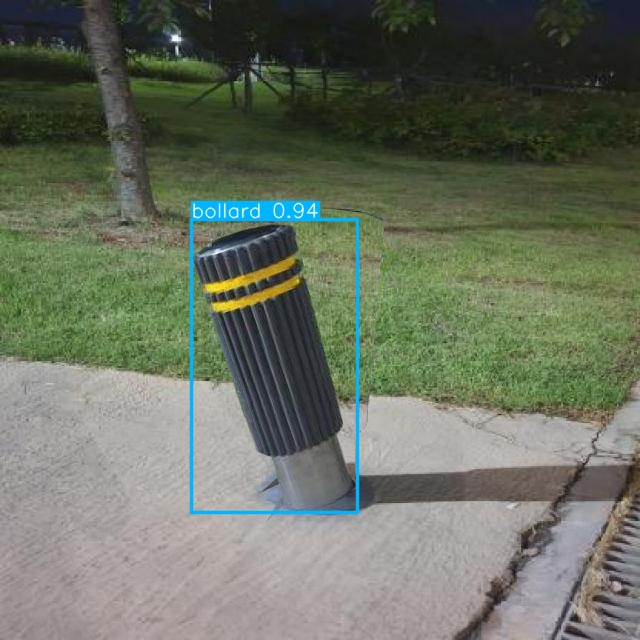

In [26]:
import cv2
from ultralytics import YOLO
from IPython.display import display, Image
from pathlib import Path

# ==============================================================================
# 1. 모델 로드 (baseline의 best.pt 경로 지정)
# ==============================================================================
MODEL_PATH = "exp_comparison/baseline/weights/best.pt"

if not Path(MODEL_PATH).exists():
    print(f"❌ 에러: 모델 가중치 파일(best.pt)을 찾을 수 없습니다: {MODEL_PATH}")
    print("앞선 하이퍼파라미터 비교표에서 baseline 폴더와 weights 폴더가 생성되었는지 확인해 주세요.")
else:
    model = YOLO(MODEL_PATH)
    print(f"🎯 모델 로드 완료: {MODEL_PATH}")

    # ==========================================================================
    # 2. 🔍 탐지할 이미지 경로 지정 (이 부분을 테스트할 이미지 경로로 수정하세요!)
    # ==========================================================================
    IMAGE_PATH = "datasets/bollard-dataset/train/images/1_jpg.rf.8b696e77dd619a0c765d7b78ed64dcfa.jpg"  # 예시 경로

    if not Path(IMAGE_PATH).exists():
        print(f"⚠️ 경고: 입력한 이미지 파일이 존재하지 않습니다: {IMAGE_PATH}")
        print("본인의 이미지 파일 경로(예: 'outside.jpg')로 변경한 후 다시 실행해 주세요.")
    else:
        # ==========================================================================
        # 3. 객체 탐지 및 후처리 시각화
        # ==========================================================================
        # conf=0.25 (신뢰도 임계값), iou=0.45 (NMS 중복 제거 임계값)
        results = model.predict(source=IMAGE_PATH, conf=0.50, iou=0.45, verbose=False)
        
        # YOLO 내장 plot() 함수를 사용하여 예측 상자와 라벨이 그려진 이미지 배열(BGR) 생성
        result_img_bgr = results[0].plot()
        
        # 4. 결과 이미지를 임시 파일로 저장 (predict 폴더가 계속 증식하는 것을 방지)
        temp_output_path = "temp_detection_result.jpg"
        cv2.imwrite(temp_output_path, result_img_bgr)
        
        print(f"🎉 객체 탐지 성공! (결과 저장 완료: {temp_output_path})")
        print("-" * 50)
        
        # 5. 주피터 노트북에 결과 이미지 인라인 출력
        display(Image(filename=temp_output_path))


# 실제 집앞에서 찍은 사진을 활용하여 (카메라 높이, 수직 각도, 세로 형식) 데이터 라벨링
iphone 12 mini로 찍어서 roboflow에서 SAM3를 활용하여 라벨링 후 직접 라벨링 검수 후 데이터 셋 로컬에 로드(testphoto 폴더)

🔍 총 7개의 테스트 이미지를 찾았습니다. 추론을 시작합니다.

📸 결과 이미지 대조표 [5/7]: KakaoTalk_Photo_2026-06-21-19-03-10 006_jpeg.rf.QnAAGcSFfqohgMfqR4n5.jpeg


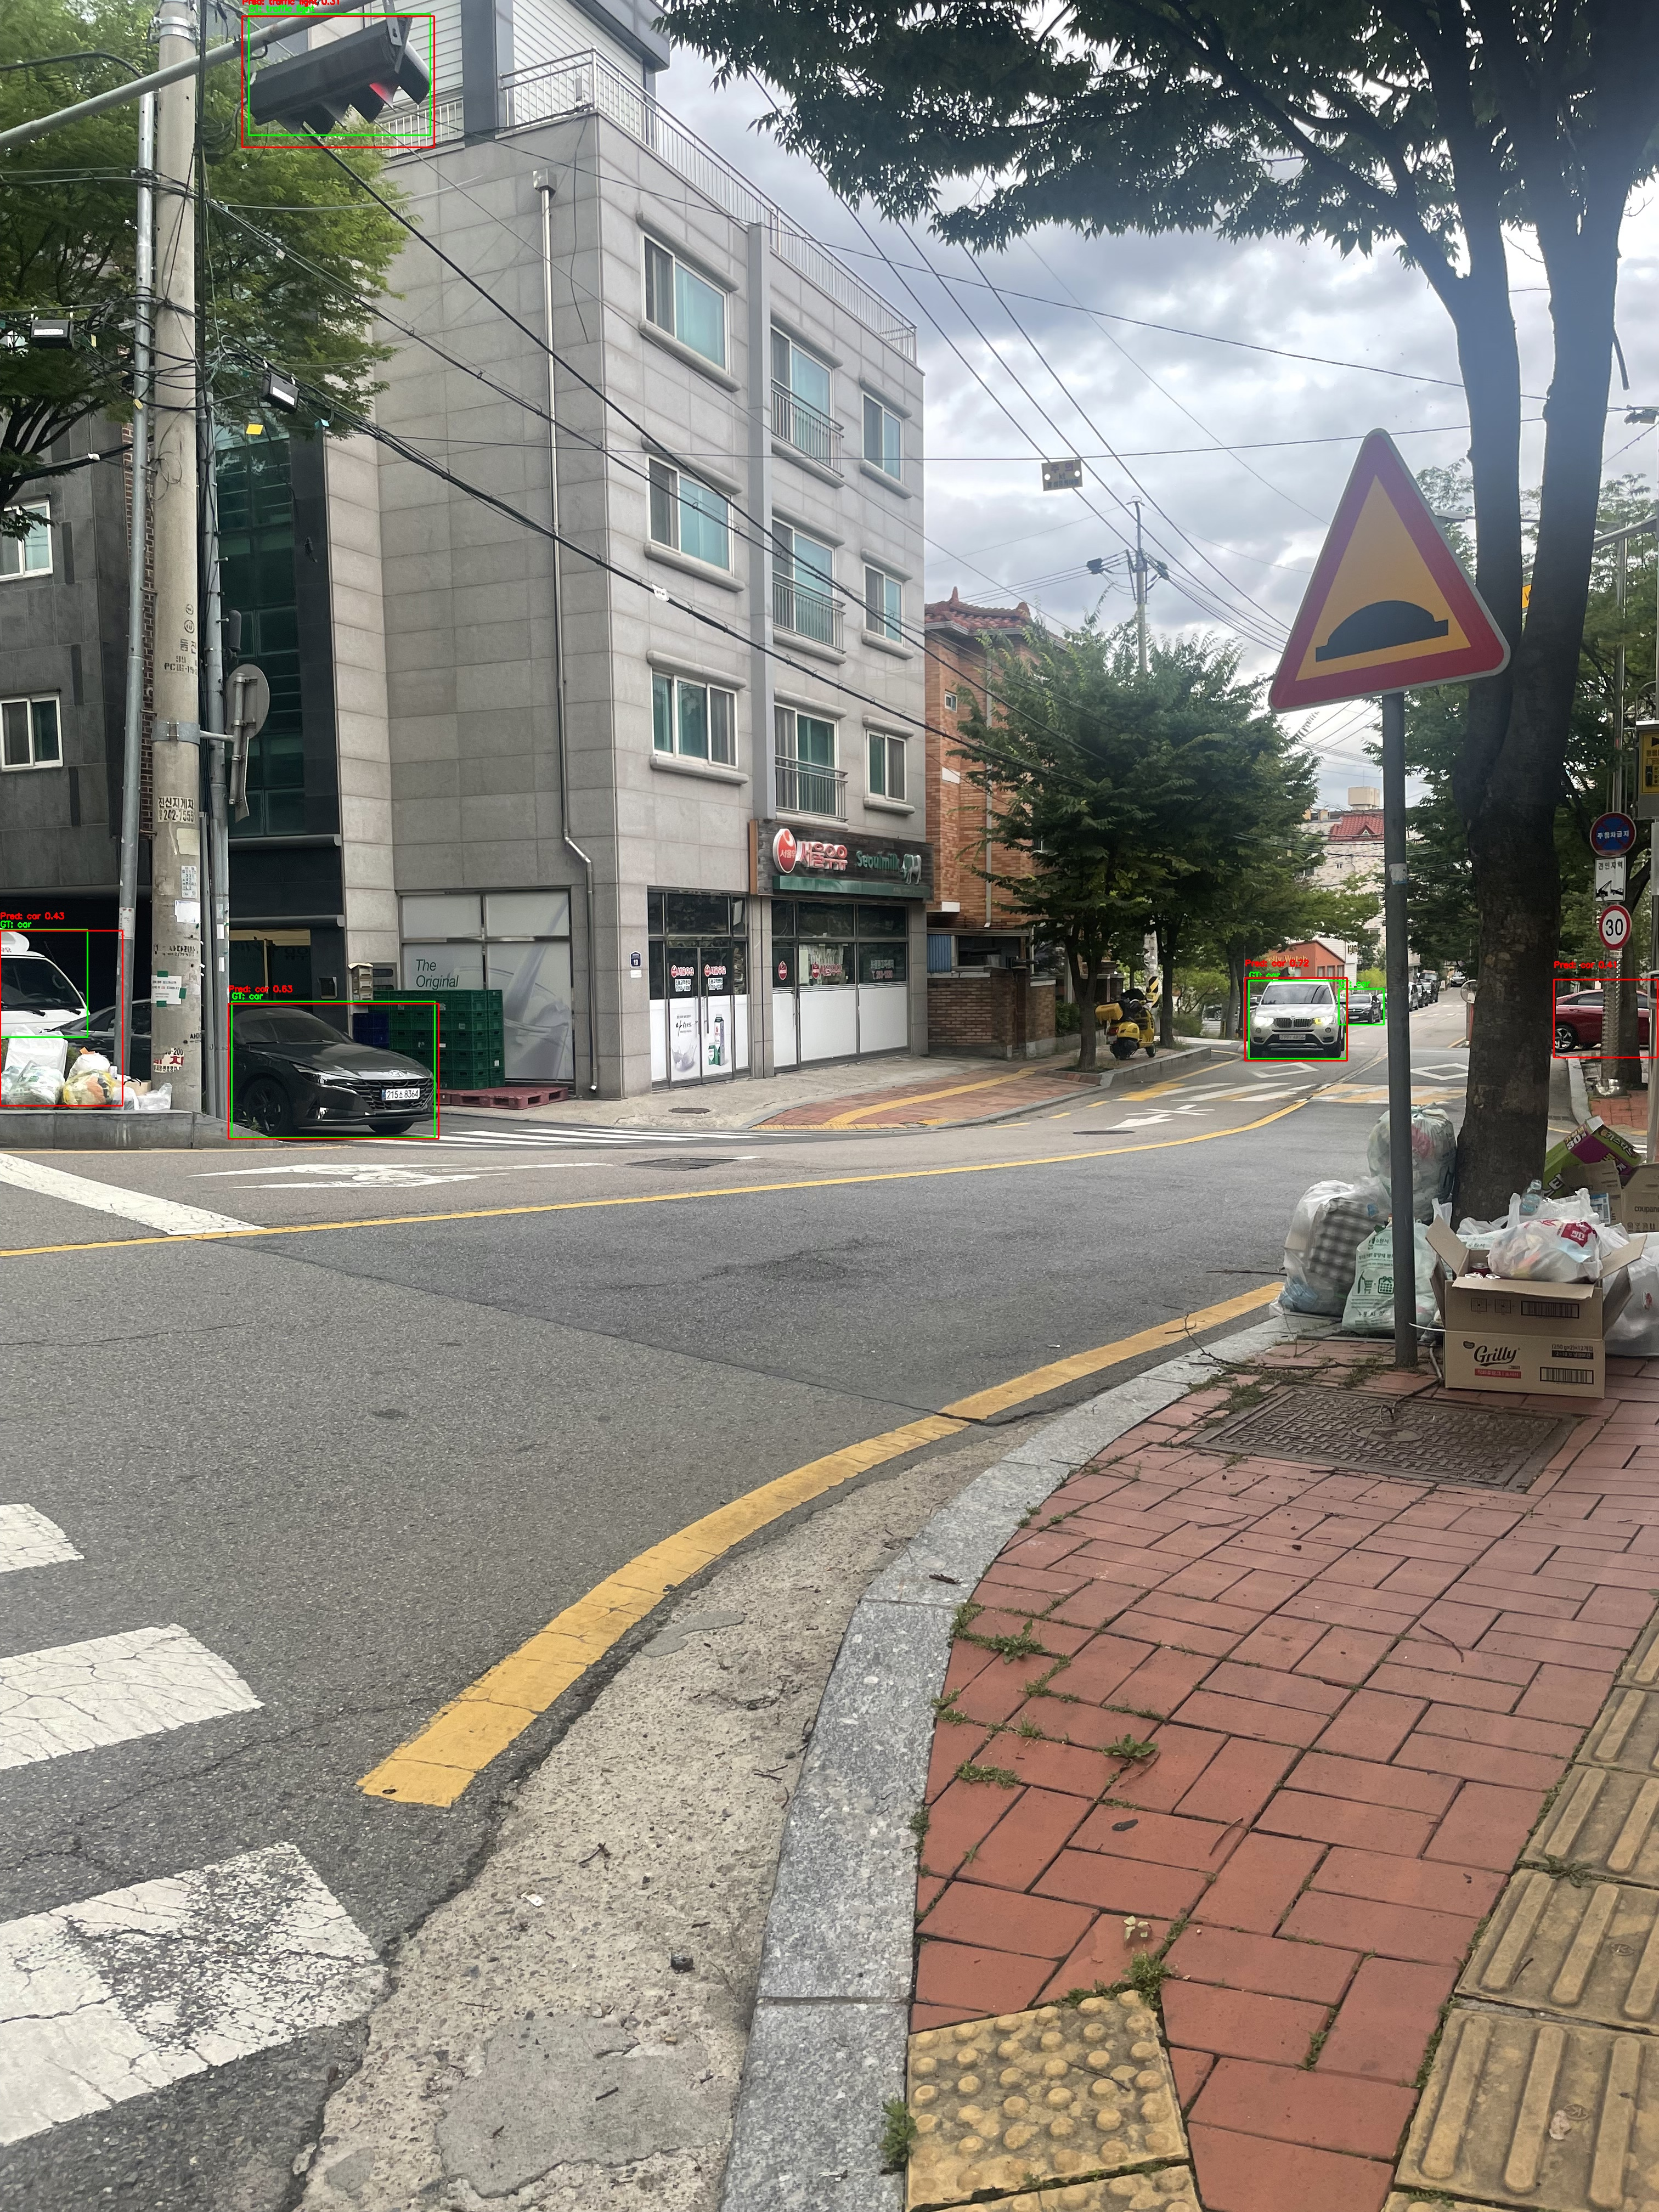


🎉 전체 7장의 결과 이미지 생성이 완료되었습니다!
📁 결과가 저장된 절대 경로: /Users/company/Downloads/drive-download-20260617T184243Z-3-001/testphoto/comparison_results


In [35]:
%matplotlib inline

import cv2
import glob
from pathlib import Path
from ultralytics import YOLO
from IPython.display import display, Image

# ==============================================================================
# 1. 경로 설정 및 12종 클래스 정의
# ==============================================================================
MODEL_PATH = "exp_comparison/baseline/weights/best.pt"
IMAGE_DIR = Path("testphoto/images")
LABEL_DIR = Path("testphoto/labels")
OUTPUT_DIR = Path("testphoto/comparison_results")  # 결과가 저장될 폴더

# 출력 폴더 생성
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 12종 클래스 이름 매핑
class_names = {
    0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'bus', 
    5: 'truck', 6: 'traffic light', 7: 'stop sign', 8: 'bench', 
    9: 'dog', 10: 'bollard', 11: 'kickboard'
}

# 모델 로드
if not Path(MODEL_PATH).exists():
    raise FileNotFoundError(f"❌ 모델 파일을 찾을 수 없습니다: {MODEL_PATH}")
model = YOLO(MODEL_PATH)

# 이미지 파일 스캔
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
image_paths = [p for p in IMAGE_DIR.glob("*") if p.suffix.lower() in IMG_EXTS]

print(f"🔍 총 {len(image_paths)}개의 테스트 이미지를 찾았습니다. 추론을 시작합니다.")

# ==============================================================================
# 2. 이미지별 루프 돌며 그리기 수행
# ==============================================================================
for idx, img_path in enumerate(image_paths):
    # 이미지 로드 및 크기 정보 획득
    img = cv2.imread(str(img_path))
    h_img, w_img, _ = img.shape
    
    # --------------------------------------------------------------------------
    # 1) 원래 라벨링 (Ground Truth) 그리기 - 초록색 (Green)
    # --------------------------------------------------------------------------
    lbl_path = LABEL_DIR / f"{img_path.stem}.txt"
    if lbl_path.exists():
        with open(lbl_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                
                class_id = int(parts[0])
                label_name = class_names.get(class_id, f"Class {class_id}")
                
                # YOLO BBox 형식([x_c, y_c, w, h])과 Polygon 형식([x1, y1, x2, y2...]) 둘 다 대응
                if len(parts) == 5:
                    x_c, y_c, w, h = [float(x) for x in parts[1:]]
                    x_min = int((x_c - w / 2) * w_img)
                    y_min = int((y_c - h / 2) * h_img)
                    x_max = int((x_c + w / 2) * w_img)
                    y_max = int((y_c + h / 2) * h_img)
                else:
                    # 다각형(Polygon)인 경우 최소/최대 좌표를 추출하여 사각형 경계 생성
                    coords = [float(x) for x in parts[1:]]
                    x_coords = [int(coords[i] * w_img) for i in range(0, len(coords), 2)]
                    y_coords = [int(coords[i+1] * h_img) for i in range(0, len(coords), 2)]
                    x_min, y_min = min(x_coords), min(y_coords)
                    x_max, y_max = max(x_coords), max(y_coords)
                
                # 초록색 박스 그리기
                cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
                # 라벨 표시 (GT: 클래스명)
                label_text = f"GT: {label_name}"
                cv2.putText(img, label_text, (x_min, y_min - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # --------------------------------------------------------------------------
    # 2) 모델 예측 (Prediction) 그리기 - 빨간색 (Red)
    # --------------------------------------------------------------------------
    results = model.predict(source=img_path, conf=0.25, iou=0.45, verbose=False)
    pred_boxes = results[0].boxes
    
    for box in pred_boxes:
        x1, y1, x2, y2 = [int(x) for x in box.xyxy[0].tolist()]
        cls_id = int(box.cls[0].item())
        conf = box.conf[0].item()
        pred_name = class_names.get(cls_id, f"Class {cls_id}")
        
        # 빨간색 박스 그리기
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
        # 라벨 표시 (Pred: 클래스명 신뢰도) - GT 글자와 겹침을 최소화하기 위해 살짝 위쪽 배치
        pred_text = f"Pred: {pred_name} {conf:.2f}"
        text_y = y1 - 22 if y1 - 22 > 0 else y1 + 15
        cv2.putText(img, pred_text, (x1, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

    # --------------------------------------------------------------------------
    # 3) 결과 이미지 저장 및 출력
    # --------------------------------------------------------------------------
    out_path = OUTPUT_DIR / img_path.name
    cv2.imwrite(str(out_path), img)
    
    # 시각적 확인을 위해 처음 3개의 결과만 주피터에 인라인으로 띄워줍니다.
    if idx == 4:
        print(f"\n📸 결과 이미지 대조표 [{idx+1}/{len(image_paths)}]: {img_path.name}")
        display(Image(filename=str(out_path)))

print(f"\n🎉 전체 {len(image_paths)}장의 결과 이미지 생성이 완료되었습니다!")
print(f"📁 결과가 저장된 절대 경로: {OUTPUT_DIR.resolve()}")


# 📦 YOLO11n INT8 TFLite 변환 코드

In [ ]:
from ultralytics import YOLO
from pathlib import Path

# 1. baseline의 best.pt 모델 가중치 경로 설정
model_path = "exp_comparison/baseline/weights/best.pt"
data_yaml_path = "datasets/coco_total/data.yaml"

if not Path(model_path).exists():
    print(f"❌ 에러: 모델 파일을 찾을 수 없습니다: {model_path}")
elif not Path(data_yaml_path).exists():
    print(f"❌ 에러: data.yaml 파일을 찾을 수 없습니다: {data_yaml_path}")
else:
    # 2. PyTorch 모델 로드
    model = YOLO(model_path)
    print("🎯 PyTorch 모델 로드 완료. TFLite INT8 양자화 변환을 시작합니다...")
    
    # 3. TFLite INT8 변환 실행
    # - format='tflite': TFLite 포맷으로 내보내기 지정
    # - int8=True: 8비트 정수형 양자화 활성화
    # - data=data_yaml_path: 양자화 보정(Calibration)을 위한 데이터셋 지정
    exported_path = model.export(
        format="tflite", 
        int8=True, 
        data=data_yaml_path
    )
    
    print("\n" + "="*50)
    print("🎉 TFLite INT8 양자화 변환 완료!")
    print(f"📁 변환 완료된 파일 경로: {exported_path}")
    print("="*50)
